In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 1. Create a synthetic dataset
np.random.seed(42)
data = {
    'age': np.random.randint(20, 60, 100),
    'salary': np.random.randint(30000, 120000, 100),
    'score': np.random.randint(50, 100, 100) + np.random.randn(100) * 5
}
df = pd.DataFrame(data)

print("Original DataFrame head:")
display(df.head())


Original DataFrame head:


,age,salary,score
0,58,119135,87.318119
1,48,65222,60.763212
2,34,107373,88.822167
3,27,109575,63.860145
4,40,114651,53.134404


In [ ]:
# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['age', 'salary', 'score']])

print("Scaled data (first 5 rows):")
display(pd.DataFrame(scaled_data, columns=['age_scaled', 'salary_scaled', 'score_scaled']).head())

Scaled data (first 5 rows):


,age_scaled,salary_scaled,score_scaled
0,1.670713,1.573929,0.851969
1,0.801003,-0.515684,-0.934875
2,-0.416591,1.118046,0.953175
3,-1.025388,1.203393,-0.726487
4,0.105235,1.400134,-1.448208


In [ ]:
# Apply PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# Create a new DataFrame for PCA components
pca_df = pd.DataFrame(data=pca_components, columns=['pca1', 'pca2'])

print("DataFrame with PCA components:")
display(pca_df.head())

print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

DataFrame with PCA components:


,pca1,pca2
0,1.832185,1.623590
1,0.522374,-0.777958
2,0.122290,1.043274
3,0.384683,-0.667386
4,1.518258,-0.986867


Explained variance ratio by each principal component:
[0.3454093  0.33153112]
Total explained variance: 0.68


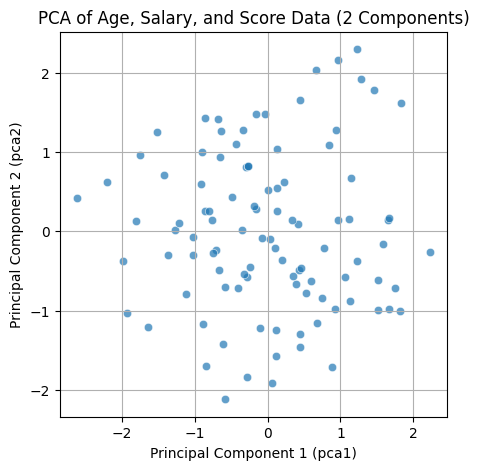

In [ ]:
# Visualize the PCA components
plt.figure(figsize=(5, 5))
sns.scatterplot(x='pca1', y='pca2', data=pca_df, alpha=0.7)
plt.title('PCA of Age, Salary, and Score Data (2 Components)')
plt.xlabel('Principal Component 1 (pca1)')
plt.ylabel('Principal Component 2 (pca2)')
plt.grid(True)
plt.show()

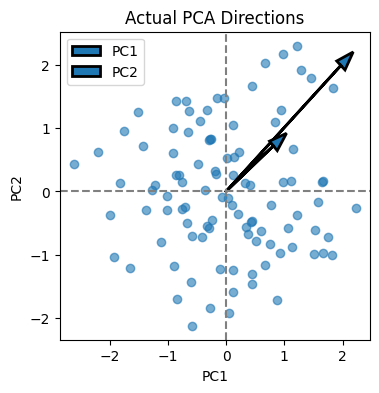

In [ ]:
plt.figure(figsize=(4,4))
plt.scatter(pca_df['pca1'], pca_df['pca2'], alpha=0.6)
# Get principal directions (in PCA space)
for i in range(len(pca.components_)):
    vector = pca.components_[i]
    # Scale for visibility
    plt.arrow(0, 0,
              vector[0]*3,
              vector[1]*3,
              head_width=0.2,
              linewidth=2,
              label=f'PC{i+1}')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Actual PCA Directions")
plt.legend()
plt.show()